# SPA613M Programming Assignment

You are part of an **IIT Kanpur** Celestial observing team studying **FRB 20220912A**, a repeating fast radio burst. This is one continuous assignment: it begins with units and time, moves through coordinate transformations and spherical calculations, develops the geometry and visibility of a source from GTC, and ends by answering progressively harder observing questions involving a FRB and a one-year all-sky GTC visibility infographic.

Use **UTC internally** for astronomical calculations. Whenever you report a civil clock time, show **IIT Kanpur time—Indian Standard Time (IST, `Asia/Kolkata`, UTC+05:30)** and retain UTC where requested.

**Total: 40 marks**  
**Optional:** Q20 carries 2 bonus marks.


## Marking Scheme

| Part | Questions | Topic | Marks |
|---|---:|---|---:|
| A | Q1–Q3 | Current time, quantities, conversions, JD/MJD, and IST | 5 |
| B | Q4–Q7 | Angles, coordinate systems, and angular separation | 8 |
| C | Q8–Q13 | GTC, LST, hour angle, transit, and altitude calculations | 12 |
| D | Q14–Q17 | Airmass, Sun, Moon, and practical visibility decisions | 9 |
| E | Q18 | Observing interval, GTC airmass figure, and interpretation | 4 |
| F | Q19 | Single-FRB visibility | 2 |
| Bonus extension | Q20 | One-year all-sky GTC animation | 2 bonus |
| **Assessed total** | **Q1–Q19** |  | **40** |


## Fixed target record

FRB 20220912A is a repeating fast radio burst. Use the following published VLBI position throughout the assignment:

- Source: `FRB 20220912A`
- ICRS/J2000 RA: `23h09m04.8989s`
- ICRS/J2000 Dec: `+48d42m23.9078s`
- Coordinate uncertainty: `5 mas`
- Dispersion measure: $219.46\,\mathrm{pc\,cm^{-3}}$
- Host redshift: $0.0771$

Source: Hewitt et al., *Milliarcsecond localization of the hyperactive repeating FRB 20220912A*, MNRAS 529, 1814–1830. The values above are frozen, so no catalogue or web query is required. [Published article](https://academic.oup.com/mnras/article/529/2/1814/7623035)

## Fixed GTC observing case

| Item | Course value |
|---|---|
| Observatory | Gran Telescopio Canarias (GTC) |
| Longitude | $-17.889^\circ$ |
| Latitude | $+28.758^\circ$ |
| Height | $2396\,\mathrm{m}$ |
| Calculation interval | `2026-08-30T12:00:00Z` through `2026-08-31T12:00:00Z` |
| Sampling | 10 minutes; both endpoints included; 145 samples |
| Minimum target altitude | $20^\circ$ |
| Permitted target airmass | finite $1\leq X\leq2.5$ |
| Astronomical darkness | Sun altitude $\leq-18^\circ$ |
| Minimum Moon separation | $30^\circ$ |

A target is observable only when **all four** target-altitude, target-airmass, Sun, and Moon-separation conditions pass simultaneously.

## Setup

Run the dependency cell before Q1. The setup supplies imports, fixed course constants, a reproducible offline astronomy configuration, an inclusive 145-sample UTC grid, IIT Kanpur formatting helpers, and a relative output directory.

In [1]:
import subprocess
import sys

REQUIRED_PACKAGES = [
    "numpy>=1.26",
    "matplotlib>=3.8",
    "astropy>=6.0",
    "astropy-iers-data",
    "tzdata",
    "healpy>=1.18",
    "astroplan>=0.10",
    "imageio>=2.31",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--disable-pip-version-check",
        *REQUIRED_PACKAGES,
    ]
)
print("Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.")

Dependencies installed: NumPy, Matplotlib, Astropy, IERS data, timezone data, healpy, astroplan, and imageio.


In [2]:
from datetime import timezone
from pathlib import Path
from zoneinfo import ZoneInfo

import astropy
import matplotlib
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import healpy as hp
import numpy as np
from astropy import units as u
from astropy.coordinates import (
    AltAz,
    Angle,
    BarycentricTrueEcliptic,
    EarthLocation,
    SkyCoord,
    get_body,
    get_sun,
    solar_system_ephemeris,
)
from astropy.time import Time
from astropy.utils import iers
from astroplan import Observer

# Keep the astronomy calculation reproducible and independent of a live IERS download.
iers.conf.auto_download = False
iers.conf.auto_max_age = None

IITK_TIMEZONE = ZoneInfo("Asia/Kolkata")

FRB_NAME = "FRB 20220912A"
FRB_RA_J2000 = "23h09m04.8989s"
FRB_DEC_J2000 = "+48d42m23.9078s"
EARLIER_POSITION_RA = "23h09m04.9s"
EARLIER_POSITION_DEC = "+48d42m25.4s"

START_UTC = "2026-08-30T12:00:00"
STOP_UTC = "2026-08-31T12:00:00"
STEP_MINUTES = 10

GTC_LONGITUDE_DEG = -17.889
GTC_LATITUDE_DEG = 28.758
GTC_HEIGHT_M = 2396.0

MIN_TARGET_ALTITUDE_DEG = 20.0
MAX_AIRMASS = 2.5
MAX_SUN_ALTITUDE_DEG = -18.0
MIN_MOON_SEPARATION_DEG = 30.0

OUTPUT_DIR = Path("assignment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# The inclusive 24-hour course grid is provided so you can focus on astronomy.
start_time = Time(START_UTC, scale="utc")
stop_time = Time(STOP_UTC, scale="utc")
step = STEP_MINUTES * u.min
number_of_steps = int(
    np.round(((stop_time - start_time) / step).to_value(u.dimensionless_unscaled))
)
times = start_time + np.arange(number_of_steps + 1) * step
assert len(times) == 145

def format_iitk(time_value):
    """Return one Astropy Time as the IIT Kanpur civil clock."""
    return time_value.to_datetime(timezone=IITK_TIMEZONE).strftime(
        "%Y-%m-%d %H:%M:%S IST"
    )

def format_utc(time_value):
    """Return one Astropy Time with an explicit UTC label."""
    return time_value.utc.strftime("%Y-%m-%d %H:%M:%S UTC")

print("Target:", FRB_NAME)
print("Observatory: Gran Telescopio Canarias (GTC)")
print("Course grid:", len(times), "samples")
print("IIT Kanpur civil timezone:", IITK_TIMEZONE)
print("Astronomical calculations use UTC; civil-time answers also show IST.")

Matplotlib is building the font cache; this may take a moment.


Target: FRB 20220912A
Observatory: Gran Telescopio Canarias (GTC)
Course grid: 145 samples
IIT Kanpur civil timezone: Asia/Kolkata
Astronomical calculations use UTC; civil-time answers also show IST.


# Part A.  Astropy foundations: time, units, and conversions (5 marks)

## Q1. Current UTC and IIT Kanpur time [1 mark]

Call `Time.now()` exactly once and store it as `now`. Print that same instant as ISO UTC and as the IIT Kanpur civil clock with an `IST` label. In one sentence, explain why two separate calls to `Time.now()` need not describe exactly the same instant.

In [3]:
now = Time.now()
print("UTC Time:", format_utc(now))
print("IIT Kanpur Time:", format_iitk(now))

UTC Time: 2026-09-06 13:15:57 UTC
IIT Kanpur Time: 2026-09-06 18:45:57 IST


Two separate calls to Time.now() describe different physical instants because the computer's internal clock advances during the time taken to execute instructions between the calls.

## Q2. Physical quantities and unit conversions [2 marks]

Create Astropy quantities for the GTC height `2396 m`, wavelength `600 nm`, coordinate uncertainty `5 mas`, cadence `10 min`, and radio frequency `1.4 GHz`. Convert them respectively to kilometres, frequency in THz using `u.spectral()`, arcseconds, hours, and wavelength in centimetres using `u.spectral()`. Print every original value beside its converted value.

In [4]:
gtc_height = 2396.0 * u.m
opt_wl = 600.0 * u.nm
coord_unc = 5.0 * u.mas
cadence = 10.0 * u.min
radio_freq = 1.4 * u.GHz

print(f"Height:       {gtc_height}  ==>  {gtc_height.to(u.km)}")
print(f"Wavelength:   {opt_wl}  ==>  {opt_wl.to(u.THz, equivalencies=u.spectral()):.4f}")
print(f"Uncertainty:  {coord_unc}  ==>  {coord_unc.to(u.arcsec)}")
print(f"Cadence:      {cadence}  ==>  {cadence.to(u.hour):.4f}")
print(f"Frequency:    {radio_freq}  ==>  {radio_freq.to(u.cm, equivalencies=u.spectral()):.4f}")

Height:       2396.0 m  ==>  2.396 km
Wavelength:   600.0 nm  ==>  499.6541 THz
Uncertainty:  5.0 mas  ==>  0.005 arcsec
Cadence:      10.0 min  ==>  0.1667 h
Frequency:    1.4 GHz  ==>  21.4137 cm


## Q3. UTC, JD, MJD, IST, and time arithmetic [2 marks]

Construct `planning_start = Time(START_UTC, scale="utc")`. Print UTC, Julian Date, Modified Julian Date, and IIT Kanpur time. Add `2.25 hour` with an Astropy quantity and print the later instant in UTC and IST. Finally verify that converting the original IST-aware Python datetime back into `Time` changes the instant by less than one microsecond.

In [5]:
planning_start = Time(START_UTC, scale="utc")
print("Planning Start UTC: ", format_utc(planning_start))
print("Julian Date (JD):   ", planning_start.jd)
print("Modified JD (MJD):  ", planning_start.mjd)
print("IITK Civil Clock:   ", format_iitk(planning_start))

later_time = planning_start + 2.25 * u.hour
print("\nLater Instant (+2.25 hr):")
print("UTC: ", format_utc(later_time))
print("IST: ", format_iitk(later_time))

py_dt = planning_start.to_datetime(timezone=IITK_TIMEZONE)
recovered_time = Time(py_dt)
diff_microsec = np.abs((recovered_time - planning_start).to_value(u.us))
print(f"\nRound-trip difference: {diff_microsec:.6e} microseconds")
assert diff_microsec < 1.0

Planning Start UTC:  2026-08-30 12:00:00 UTC
Julian Date (JD):    2461283.0
Modified JD (MJD):   61282.5
IITK Civil Clock:    2026-08-30 17:30:00 IST

Later Instant (+2.25 hr):
UTC:  2026-08-30 14:15:00 UTC
IST:  2026-08-30 19:45:00 IST

Round-trip difference: 0.000000e+00 microseconds


# Part B. Angles and coordinate transformations (8 marks)


## Q4. Parse angles and construct an ICRS coordinate [2 marks]

Parse the target RA and Dec with `Angle`, then construct scalar `frb_icrs` with `SkyCoord`. Print RA and Dec in decimal degrees and padded sexagesimal notation. Verify RA $347.2704120833^\circ$ and Dec $+48.7066410556^\circ$ within $10^{-8}$ degree. Explain why RA commonly uses hours while Dec uses degrees.

In [6]:
ra_angle = Angle(FRB_RA_J2000)
dec_angle = Angle(FRB_DEC_J2000)
frb_icrs = SkyCoord(ra=ra_angle, dec=dec_angle, frame="icrs")

print(f"RA  (decimal deg): {frb_icrs.ra.deg:.10f}°")
print(f"Dec (decimal deg): {frb_icrs.dec.deg:.10f}°")
print(f"RA  (sexagesimal): {frb_icrs.ra.to_string(unit=u.hour, sep='hms', precision=4, pad=True)}")
print(f"Dec (sexagesimal): {frb_icrs.dec.to_string(unit=u.deg, sep='dms', precision=4, pad=True)}")

assert np.isclose(frb_icrs.ra.deg, 347.2704120833, atol=1e-8)
assert np.isclose(frb_icrs.dec.deg, 48.7066410556, atol=1e-8)

RA  (decimal deg): 347.2704120833°
Dec (decimal deg): 48.7066410556°
RA  (sexagesimal): 23h09m04.8989s
Dec (sexagesimal): 48d42m23.9078s


Right Ascension is historically and operationally measured in hours (0 to 24h) because it corresponds directly with the Earth's diurnal rotation relative to sidereal time (15° per hour), making hour angle calculations straightforward; Declination measures angular distance north or south of the celestial equator (-90° to +90°), which naturally uses degrees.

## Q5. ICRS to Galactic and back [2 marks]

Transform `frb_icrs` to Galactic coordinates and print Galactic longitude $l$ and latitude $b$. Transform the result back to ICRS, calculate the round-trip separation in microarcseconds, and explain what a tiny non-zero residual represents.

In [7]:
frb_galactic = frb_icrs.galactic
print(f"Galactic l: {frb_galactic.l.deg:.6f}°")
print(f"Galactic b: {frb_galactic.b.deg:.6f}°")

frb_roundtrip_icrs = frb_galactic.transform_to("icrs")
sep_uarcsec = frb_icrs.separation(frb_roundtrip_icrs).to_value(u.uarcsec)
print(f"Round-trip separation: {sep_uarcsec:.6e} microarcseconds")

Galactic l: 106.064961°
Galactic b: -10.784176°
Round-trip separation: 3.107329e-04 microarcseconds


The tiny residual represents floating-point roundoff error inherent in matrix coordinate rotations and trigonometric conversions.

## Q6. ICRS to Ecliptic and back [2 marks]

Transform `frb_icrs` to barycentric true ecliptic coordinates at equinox J2000. Print ecliptic longitude $\lambda$ and latitude $\beta$ in degrees, verify their valid ranges, transform the result back to ICRS, and calculate the round-trip separation in microarcseconds. Explain what the ecliptic plane and the value of $\beta$ mean physically.

In [8]:
frb_ecliptic = frb_icrs.transform_to(BarycentricTrueEcliptic(equinox="J2000"))
print(f"Ecliptic Longitude (lambda): {frb_ecliptic.lon.deg:.6f}°")
print(f"Ecliptic Latitude (beta):     {frb_ecliptic.lat.deg:.6f}°")

assert 0.0 <= frb_ecliptic.lon.deg < 360.0
assert -90.0 <= frb_ecliptic.lat.deg <= 90.0

frb_ecl_to_icrs = frb_ecliptic.transform_to("icrs")
roundtrip_ecl_sep = frb_icrs.separation(frb_ecl_to_icrs).to_value(u.uarcsec)
print(f"Round-trip separation: {roundtrip_ecl_sep:.6e} microarcseconds")

Ecliptic Longitude (lambda): 14.411188°
Ecliptic Latitude (beta):     48.346958°
Round-trip separation: 0.000000e+00 microarcseconds


The ecliptic plane represents Earth's geometric orbital plane around the Sun, and $\beta$ is the angular elevation of the target perpendicular to that plane. 

## Q7. Angular separation [2 marks]

Construct `earlier_position` from `23h09m04.9s`, `+48d42m25.4s`. Calculate the great-circle separation manually from

$$\cos(\Delta\theta)=\sin\delta_1\sin\delta_2+\cos\delta_1\cos\delta_2\cos(\alpha_2-\alpha_1).$$

Use radians inside NumPy, clip the computed cosine to $[-1,1]$, and report $\Delta\theta$ in arcseconds and milliarcseconds. Compare with `frb_icrs.separation(earlier_position)` and require agreement within $10^{-6}$ arcsecond.

In [12]:
# Construct earlier_position
earlier_position = SkyCoord(EARLIER_POSITION_RA, EARLIER_POSITION_DEC, frame="icrs")

# Spherical coordinates in radians as double precision
alpha1 = np.float64(frb_icrs.ra.rad)
delta1 = np.float64(frb_icrs.dec.rad)
alpha2 = np.float64(earlier_position.ra.rad)
delta2 = np.float64(earlier_position.dec.rad)

# Great-circle cosine formula
cos_dtheta = np.sin(delta1) * np.sin(delta2) + np.cos(delta1) * np.cos(delta2) * np.cos(alpha2 - alpha1)
cos_dtheta_clipped = np.clip(cos_dtheta, -1.0, 1.0)

# Compute separation in radians, convert to Angle
delta_theta_rad = np.arccos(cos_dtheta_clipped)
delta_theta = Angle(delta_theta_rad, unit=u.rad)

# Astropy separation
sep_astropy = frb_icrs.separation(earlier_position)

# Report in arcseconds and milliarcseconds
print(f"Manual Separation:  {delta_theta.arcsec:.8f}\" ({delta_theta.to_value(u.mas):.4f} mas)")
print(f"Astropy Separation: {sep_astropy.arcsec:.8f}\" ({sep_astropy.to_value(u.mas):.4f} mas)")

alpha1 = np.longdouble(frb_icrs.ra.rad)
delta1 = np.longdouble(frb_icrs.dec.rad)
alpha2 = np.longdouble(earlier_position.ra.rad)
delta2 = np.longdouble(earlier_position.dec.rad)

cos_dtheta = np.sin(delta1) * np.sin(delta2) + np.cos(delta1) * np.cos(delta2) * np.cos(alpha2 - alpha1)
cos_dtheta_clipped = np.clip(cos_dtheta, -1.0, 1.0)

delta_theta_rad = np.arccos(cos_dtheta_clipped)
delta_theta = Angle(float(delta_theta_rad), unit=u.rad)

sep_astropy = frb_icrs.separation(earlier_position)

diff_arcsec = np.abs(delta_theta.to_value(u.arcsec) - sep_astropy.to_value(u.arcsec))
print(f"Difference: {diff_arcsec:.10e} arcsec")
assert diff_arcsec < 1e-6

Manual Separation:  1.49223745" (1492.2374 mas)
Astropy Separation: 1.49223973" (1492.2397 mas)
Difference: 1.0396123962e-09 arcsec


# Part C. GTC geometry, LST, transit, and altitude calculations (12 marks)

## Q8. Define the GTC observing site [1 mark]

Construct `gtc_location` with `EarthLocation.from_geodetic`, attaching units to the frozen longitude, latitude, and height. Print the recovered geodetic values. State what the negative longitude sign means.

In [13]:
gtc_location = EarthLocation.from_geodetic(
    lon=GTC_LONGITUDE_DEG * u.deg,
    lat=GTC_LATITUDE_DEG * u.deg,
    height=GTC_HEIGHT_M * u.m
)
print(f"GTC Recovered Lon:    {gtc_location.geodetic.lon.to(u.deg):.4f}")
print(f"GTC Recovered Lat:    {gtc_location.geodetic.lat.to(u.deg):.4f}")
print(f"GTC Recovered Height: {gtc_location.geodetic.height.to(u.m):.1f}")

GTC Recovered Lon:    -17.8890 deg
GTC Recovered Lat:    28.7580 deg
GTC Recovered Height: 2396.0 m


The negative longitude sign specifies that GTC is located west of the Prime Meridian (Greenwich).

## Q9. Calculate GTC LST and hour angle at one instant [2 marks]

At `2026-08-31T00:00:00Z`, calculate apparent GTC Local Sidereal Time and target hour angle $H=\mathrm{LST}-\alpha$, wrapped at $\pm12$ hours. Print UTC, IIT Kanpur time, LST, and hour angle. From the sign of $H$, state whether the target is east of the meridian, transiting, or west of the meridian.

In [14]:
t_q9 = Time("2026-08-31T00:00:00", scale="utc")
lst_q9 = t_q9.sidereal_time("apparent", longitude=gtc_location.lon)
ha_q9 = (lst_q9 - frb_icrs.ra).wrap_at(12 * u.hourangle)

print("UTC:        ", format_utc(t_q9))
print("IST:        ", format_iitk(t_q9))
print(f"GTC LST:     {lst_q9.to_string(unit=u.hour, sep='hms', precision=2)}")
print(f"Hour Angle:  {ha_q9.to_string(unit=u.hour, sep='hms', precision=2)} ({ha_q9.to(u.deg):.4f})")

if ha_q9.hour < -0.01:
    print("Position: Target is East of the meridian.")
elif ha_q9.hour > 0.01:
    print("Position: Target is West of the meridian.")
else:
    print("Position: Target is transiting.")

UTC:         2026-08-31 00:00:00 UTC
IST:         2026-08-31 05:30:00 IST
GTC LST:     21h25m12.21s
Hour Angle:  -1h43m52.69s (-25.9695 deg)
Position: Target is East of the meridian.


## Q10. Find the nearest sampled meridian transit [2 marks]

Calculate apparent GTC LST and wrapped hour angle for all 145 samples. Locate the nearest sampled meridian transit by minimizing absolute hour angle. Print the sample index, UTC, IIT Kanpur time, LST, and hour angle. Explain why this is a sampled approximation rather than the exact transit instant.

In [15]:
lst_grid = times.sidereal_time("apparent", longitude=gtc_location.lon)
ha_grid = (lst_grid - frb_icrs.ra).wrap_at(12 * u.hourangle)

transit_idx = np.argmin(np.abs(ha_grid.deg))
t_transit = times[transit_idx]

print(f"Sample Index: {transit_idx}")
print("Transit UTC:  ", format_utc(t_transit))
print("Transit IST:  ", format_iitk(t_transit))
print(f"GTC LST:       {lst_grid[transit_idx].to_string(unit=u.hour, sep='hms', precision=2)}")
print(f"Hour Angle:    {ha_grid[transit_idx].to_string(unit=u.hour, sep='hms', precision=2)}")

Sample Index: 82
Transit UTC:   2026-08-31 01:40:00 UTC
Transit IST:   2026-08-31 07:10:00 IST
GTC LST:       23h05m28.63s
Hour Angle:    -0h03m36.27s


This is a sampled approximation because the exact instant of transit ($H = 0$) occurs continuously between the discrete 10-minute grid points.

## Q11. Predict transit altitude and zenith distance [2 marks]

For an upper meridian transit, use $h_{\mathrm{transit}}=90^\circ-|\phi-\delta|$, where $\phi$ is GTC latitude and $\delta$ is target declination. Calculate the predicted altitude and the lecture relation $z=90^\circ-h$ for zenith distance. Then transform the target to a vacuum `AltAz` frame for all grid times, find the largest sampled altitude and its zenith distance, and compare the analytic and Astropy values.

In [16]:
phi = gtc_location.lat
delta = frb_icrs.dec

h_transit_analytic = 90.0 * u.deg - np.abs(phi - delta)
z_transit_analytic = 90.0 * u.deg - h_transit_analytic

altaz_frame = AltAz(obstime=times, location=gtc_location)
frb_altaz_all = frb_icrs.transform_to(altaz_frame)

max_alt_idx = np.argmax(frb_altaz_all.alt.deg)
max_alt_astropy = frb_altaz_all.alt[max_alt_idx]
min_zd_astropy = 90.0 * u.deg - max_alt_astropy

print(f"Analytic Transit Altitude:     {h_transit_analytic:.6f}")
print(f"Analytic Transit Zenith Dist:  {z_transit_analytic:.6f}")
print(f"Astropy Max Sample Altitude:   {max_alt_astropy:.6f}")
print(f"Astropy Min Zenith Dist:       {min_zd_astropy:.6f}")
print(f"Difference:                    {np.abs(h_transit_analytic - max_alt_astropy).to(u.arcsec):.2f}")

Analytic Transit Altitude:     70.051359 deg
Analytic Transit Zenith Dist:  19.948641 deg
Astropy Max Sample Altitude:   69.883911 deg
Astropy Min Zenith Dist:       20.116089 deg
Difference:                    602.81 arcsec


## Q12. Calculate altitude before, at, and after transit [3 marks]

At samples two hours before transit, nearest transit, and two hours after transit, calculate altitude from

$$\sin h=\sin\phi\sin\delta+\cos\phi\cos\delta\cos H.$$

Print UTC, IST, hour angle, calculated altitude, Astropy altitude, and their difference for all three samples. State the physical pattern you see as the source crosses the meridian.

In [17]:
step_offset = 12
sample_indices = [transit_idx - step_offset, transit_idx, transit_idx + step_offset]
sample_labels = ["2 Hours Before Transit", "Nearest Transit", "2 Hours After Transit"]

for idx, label in zip(sample_indices, sample_labels):
    t_samp = times[idx]
    ha_val = ha_grid[idx]
    sin_h = np.sin(phi.rad) * np.sin(delta.rad) + np.cos(phi.rad) * np.cos(delta.rad) * np.cos(ha_val.rad)
    calc_alt = np.arcsin(np.clip(sin_h, -1.0, 1.0)) * u.rad
    astropy_alt = frb_altaz_all.alt[idx]

    print(f"\n--- {label} (Index {idx}) ---")
    print(f"UTC: {format_utc(t_samp)} | IST: {format_iitk(t_samp)}")
    print(f"Hour Angle:        {ha_val.to_string(unit=u.hour, precision=2)}")
    print(f"Formula Altitude:  {calc_alt.to(u.deg):.6f}")
    print(f"Astropy Altitude:  {astropy_alt.to(u.deg):.6f}")
    print(f"Difference:        {np.abs(calc_alt - astropy_alt).to(u.arcsec):.4f}")


--- 2 Hours Before Transit (Index 70) ---
UTC: 2026-08-30 23:40:00 UTC | IST: 2026-08-31 05:10:00 IST
Hour Angle:        -2h03m55.98s
Formula Altitude:  59.031946 deg
Astropy Altitude:  58.781572 deg
Difference:        901.3464 arcsec

--- Nearest Transit (Index 82) ---
UTC: 2026-08-31 01:40:00 UTC | IST: 2026-08-31 07:10:00 IST
Hour Angle:        -0h03m36.27s
Formula Altitude:  70.039347 deg
Astropy Altitude:  69.883911 deg
Difference:        559.5706 arcsec

--- 2 Hours After Transit (Index 94) ---
UTC: 2026-08-31 03:40:00 UTC | IST: 2026-08-31 09:10:00 IST
Hour Angle:        1h56m43.45s
Formula Altitude:  60.063047 deg
Astropy Altitude:  60.162611 deg
Difference:        358.4328 arcsec


The altitude exhibits symmetric rising and setting geometry: it rises as it approaches the meridian from the east, reaches its maximum elevation at transit, and symmetrically decreases as it sets to the west.

## Q13. Calculate how long the source stays above 20 degrees [2 marks]

Solve the altitude equation for the limiting hour angle:

$$\cos H_0=\frac{\sin h_{\min}-\sin\phi\sin\delta}{\cos\phi\cos\delta}.$$

For $h_{\min}=20^\circ$, calculate $H_0$ in degrees and sidereal hours, then estimate the total interval $2H_0$ during which the source is above the altitude limit. Compare this with the number of grid samples above $20^\circ$.

In [19]:
h_min = 20.0 * u.deg

# Use .to_value(u.rad) to safely extract dimensionless values in radians
phi_rad = gtc_location.lat.to_value(u.rad)
delta_rad = frb_icrs.dec.to_value(u.rad)
h_min_rad = h_min.to_value(u.rad)

# Limiting hour angle formula
cos_H0 = (np.sin(h_min_rad) - np.sin(phi_rad) * np.sin(delta_rad)) / (np.cos(phi_rad) * np.cos(delta_rad))
cos_H0_clipped = np.clip(cos_H0, -1.0, 1.0)

H0_rad = np.arccos(cos_H0_clipped)
H0_deg = np.degrees(H0_rad) * u.deg
H0_hours = (H0_deg.to_value(u.deg) / 15.0) * u.hour
total_duration_hours = 2.0 * H0_hours

print(f"H0:                     {H0_deg:.4f} ({H0_hours:.4f} sidereal hours)")
print(f"Total Theoretical Time: {total_duration_hours:.4f} sidereal hours ({total_duration_hours.to_value(u.min):.1f} min)")

# Samples in the grid satisfying alt >= 20°
samples_above_20 = np.sum(frb_altaz_all.alt.to_value(u.deg) >= 20.0)
sampled_time = samples_above_20 * 10.0 * u.min

print(f"Samples above 20°:      {samples_above_20} ({sampled_time.to(u.hour):.4f})")

H0:                     91.9275 deg (6.1285 h sidereal hours)
Total Theoretical Time: 12.2570 h sidereal hours (735.4 min)
Samples above 20°:      74 (12.3333 h)


# Part D. Airmass, Sun, Moon, and practical visibility (9 marks)

## Q14. Calculate a physically safe target airmass [2 marks]

Convert `frb_gtc_altaz.secz` to a float array named `target_airmass`. Replace entries with `NaN` whenever the target is at or below the horizon, the value is non-finite, or the value is below 1. Print the finite range, best airmass with UTC and IST, and the number of samples satisfying $1\leq X\leq2.5$. Explain why below-horizon values must not be used.

In [20]:
target_secz = frb_altaz_all.secz.value.copy()
invalid_mask = (frb_altaz_all.alt.deg <= 0.0) | (~np.isfinite(target_secz)) | (target_secz < 1.0)
target_airmass = np.where(invalid_mask, np.nan, target_secz)

best_idx = np.nanargmin(target_airmass)
samples_valid_airmass = np.sum((target_airmass >= 1.0) & (target_airmass <= MAX_AIRMASS))

print(f"Finite Airmass Range: {np.nanmin(target_airmass):.3f} to {np.nanmax(target_airmass):.3f}")
print(f"Best Airmass:         {target_airmass[best_idx]:.4f} at index {best_idx}")
print(f"Best Airmass UTC:     {format_utc(times[best_idx])}")
print(f"Best Airmass IST:     {format_iitk(times[best_idx])}")
print(f"Samples (1 <= X <= 2.5): {samples_valid_airmass}")

Finite Airmass Range: 1.065 to 55.338
Best Airmass:         1.0650 at index 82
Best Airmass UTC:     2026-08-31 01:40:00 UTC
Best Airmass IST:     2026-08-31 07:10:00 IST
Samples (1 <= X <= 2.5): 68


Below the horizon ($h \le 0^\circ$), zenith angle $z \ge 90^\circ$, causing plane-parallel $\sec(z)$ to diverge or become negative, which is physically meaningless for optical path length calculations.

### Moon-conditions

Use the following simplified **course classification**. These labels are provided for this assignment; they are not universal observatory definitions.

| Label | Rule |
|---|---|
| `Unknown` | At least one of Moon altitude, Moon–target separation, or illuminated fraction is non-finite. |
| `Gray` | All three inputs are finite and neither the `Bright` nor `Dark` rule below applies. |
| `Bright` | The illuminated fraction is at least 0.70 **and** Moon altitude is above $10^\circ$, **or** Moon–target separation is at most $45^\circ$. |
| `Dark` | Moon altitude is below $0^\circ$, **or** Moon–target separation is at least $90^\circ$ **and** illuminated fraction is at most 0.25. |

Apply `Bright` first and `Dark` second. Therefore, if both rules happen to pass, the final label is `Dark`.

## Q15. Calculate Sun and Moon observing conditions [2 marks]

Using Astropy's built-in ephemeris, calculate arrays of Sun altitude, Moon altitude, Moon airmass, Moon–target separation, and approximate illuminated fraction $f=(1-\cos\epsilon)/2$, where $\epsilon$ is geocentric Sun–Moon elongation. Keep Moon airmass only from 1 to 3 and above the horizon. Classify each sample as Dark, Bright, Gray, or Unknown using the printed course rules, then print the diagnostic values and Moon label at transit.

In [21]:
sun_coords = get_sun(times).transform_to(altaz_frame)
moon_coords = get_body("moon", times).transform_to(altaz_frame)

sun_altitude = sun_coords.alt.deg
moon_altitude = moon_coords.alt.deg

moon_secz = moon_coords.secz.value.copy()
moon_airmass = np.where((moon_coords.alt.deg > 0.0) & np.isfinite(moon_secz) & (moon_secz >= 1.0) & (moon_secz <= 3.0), moon_secz, np.nan)
moon_separation = frb_altaz_all.separation(moon_coords).deg

elongation = get_sun(times).separation(get_body("moon", times))
moon_frac = (1.0 - np.cos(elongation.rad)) / 2.0

moon_labels = []
for i in range(len(times)):
    alt_m, sep_m, f_m = moon_altitude[i], moon_separation[i], moon_frac[i]
    if not (np.isfinite(alt_m) and np.isfinite(sep_m) and np.isfinite(f_m)):
        moon_labels.append("Unknown")
        continue
    is_bright = ((f_m >= 0.70) and (alt_m > 10.0)) or (sep_m <= 45.0)
    is_dark = (alt_m < 0.0) or ((sep_m >= 90.0) and (f_m <= 0.25))
    if is_dark:
        moon_labels.append("Dark")
    elif is_bright:
        moon_labels.append("Bright")
    else:
        moon_labels.append("Gray")
moon_labels = np.array(moon_labels)

print(f"Sun Alt at Transit:      {sun_altitude[transit_idx]:.2f}°")
print(f"Moon Alt at Transit:     {moon_altitude[transit_idx]:.2f}°")
print(f"Moon Sep at Transit:     {moon_separation[transit_idx]:.2f}°")
print(f"Illum Frac at Transit:   {moon_frac[transit_idx]:.3f}")
print(f"Moon Label at Transit:   {moon_labels[transit_idx]}")

Sun Alt at Transit:      -51.96°
Moon Alt at Transit:     59.10°
Moon Sep at Transit:     45.23°
Illum Frac at Transit:   0.908
Moon Label at Transit:   Bright


## Q16. Implement the visibility function [3 marks]

Write exactly

```python
visibility(altitude, airmass, sun_altitude, moon_separation)
```

It must validate four equal one-dimensional arrays and return one Boolean array. A sample is `True` only when altitude is at least $20^\circ$, airmass is finite and from 1 to 2.5, Sun altitude is at most $-18^\circ$, and Moon separation is at least $30^\circ$. Group every element-wise comparison with parentheses and join the results with `&`, not Python `and`. Print the independent condition counts, the combined count, and the overall yes/no answer.

In [28]:
def visibility(altitude, airmass, sun_altitude, moon_separation):
    arr_alt = np.asarray(altitude)
    arr_air = np.asarray(airmass)
    arr_sun = np.asarray(sun_altitude)
    arr_moon = np.asarray(moon_separation)

    assert arr_alt.shape == arr_air.shape == arr_sun.shape == arr_moon.shape
    assert arr_alt.ndim == 1

    cond_alt = (arr_alt >= 20.0)
    cond_air = (np.isfinite(arr_air)) & (arr_air >= 1.0) & (arr_air <= 2.5)
    cond_sun = (arr_sun <= -18.0)
    cond_moon = (arr_moon >= 30.0)

    return (cond_alt) & (cond_air) & (cond_sun) & (cond_moon)

preferred_visibility = visibility(frb_altaz_all.alt.deg, target_airmass, sun_altitude, moon_separation)

print("Individual Condition Counts:")
print(f"  Altitude >= 20°:          {np.sum(frb_altaz_all.alt.deg >= 20.0)}")
print(f"  Airmass in [1.0, 2.5]:    {np.sum(np.isfinite(target_airmass) & (target_airmass >= 1.0) & (target_airmass <= 2.5))}")
print(f"  Sun Altitude <= -18°:     {np.sum(sun_altitude <= -18.0)}")
print(f"  Moon Separation >= 30°:   {np.sum(moon_separation >= 30.0)}")
print(f"Combined Observable Samples: {np.sum(preferred_visibility)}")
print(f"Overall Observable?         {'YES' if np.any(preferred_visibility) else 'NO'}")

Individual Condition Counts:
  Altitude >= 20°:          74
  Airmass in [1.0, 2.5]:    68
  Sun Altitude <= -18°:     51
  Moon Separation >= 30°:   145
Combined Observable Samples: 51
Overall Observable?         YES


## Q17. Does transit automatically mean visible? [2 marks]

Evaluate the target at (a) the nearest sampled transit from Q10 and (b) `2026-08-31T06:00:00Z`, when it is still passing through the western sky. For each instant, print UTC, IST, altitude, airmass, Sun altitude, Moon separation, the pass/fail result of every condition, and the final result from `preferred_visibility`. Explain why high altitude or meridian transit alone cannot guarantee observability.

In [24]:
sample_a_idx = transit_idx

target_time_b = Time("2026-08-31T06:00:00", scale="utc")
sample_b_idx = int(np.argmin(np.abs(times - target_time_b)))

for name, idx in [("Nearest Transit", sample_a_idx), ("Western Sky (06:00 UTC)", sample_b_idx)]:
    t_val = times[idx]
    alt_val = frb_altaz_all.alt[idx].to_value(u.deg)
    air_val = target_airmass[idx]
    sun_val = sun_altitude[idx]
    moon_val = moon_separation[idx]
    vis_val = preferred_visibility[idx]
    
    cond_alt = alt_val >= 20.0
    cond_air = np.isfinite(air_val) and (1.0 <= air_val <= 2.5)
    cond_sun = sun_val <= -18.0
    cond_moon = moon_val >= 30.0
    
    print(f"\n--- Diagnostic for {name} (Index {idx}) ---")
    print(f"Time (UTC):       {format_utc(t_val)}")
    print(f"Time (IST):       {format_iitk(t_val)}")
    print(f"Target Alt:       {alt_val:.2f}°  --> Pass: {cond_alt}")
    print(f"Target Airmass:   {air_val:.3f}   --> Pass: {cond_air}")
    print(f"Sun Altitude:     {sun_val:.2f}°  --> Pass: {cond_sun}")
    print(f"Moon Separation:  {moon_val:.2f}°  --> Pass: {cond_moon}")
    print(f"Observable:       {vis_val}")


--- Diagnostic for Nearest Transit (Index 82) ---
Time (UTC):       2026-08-31 01:40:00 UTC
Time (IST):       2026-08-31 07:10:00 IST
Target Alt:       69.88°  --> Pass: True
Target Airmass:   1.065   --> Pass: True
Sun Altitude:     -51.96°  --> Pass: True
Moon Separation:  45.23°  --> Pass: True
Observable:       True

--- Diagnostic for Western Sky (06:00 UTC) (Index 108) ---
Time (UTC):       2026-08-31 06:00:00 UTC
Time (IST):       2026-08-31 11:30:00 IST
Target Alt:       37.99°  --> Pass: True
Target Airmass:   1.625   --> Pass: True
Sun Altitude:     -11.28°  --> Pass: False
Moon Separation:  44.70°  --> Pass: True
Observable:       False


High altitude or meridian transit only confirms that the target is geometrically elevated and accessible at low airmass. True astronomical observability strictly requires simultaneous darkness (Sun altitude $\leq -18^\circ$) and moon avoidance; for daytime or twilight transits, sunlight overwhelms the detector despite optimal target coordinates.

# Part E. Observing and scheduling GTC (4 marks)

## Q18. Report the observing interval and make GTC airmass figure [4 marks]

Write `stitch_windows(times, visibility_state)` to return consecutive inclusive sample-centre intervals, including empty, isolated, separated, and final-sample cases. Apply it to `preferred_visibility`. Report each interval in IIT Kanpur time and UTC, its sample-centre duration, best target airmass, and midpoint Moon label.

Then make **one GTC airmass figure** and save it as `assignment_outputs/frb_20220912a_gtc_airmass.png`. Use a solid blue target curve, dashed gray Moon curve, an inverted 3-to-1 airmass axis, the 2.5 limit, scheduler-style twilight/night bands, green shading for calculated observable intervals, black markers for observable samples, IIT Kanpur time on the main x-axis, an aligned UTC axis above, a legend, date rollover, units, and an explanatory caption. State the final scientific conclusion and one limitation of the 10-minute grid.

Window: 2026-08-30 21:00:00 UTC to 2026-08-31 05:20:00 UTC
   IST: 2026-08-31 02:30:00 IST to 2026-08-31 10:50:00 IST
   Duration: 8.50 hr | Best Airmass: 1.065 | Midpoint Moon: Bright


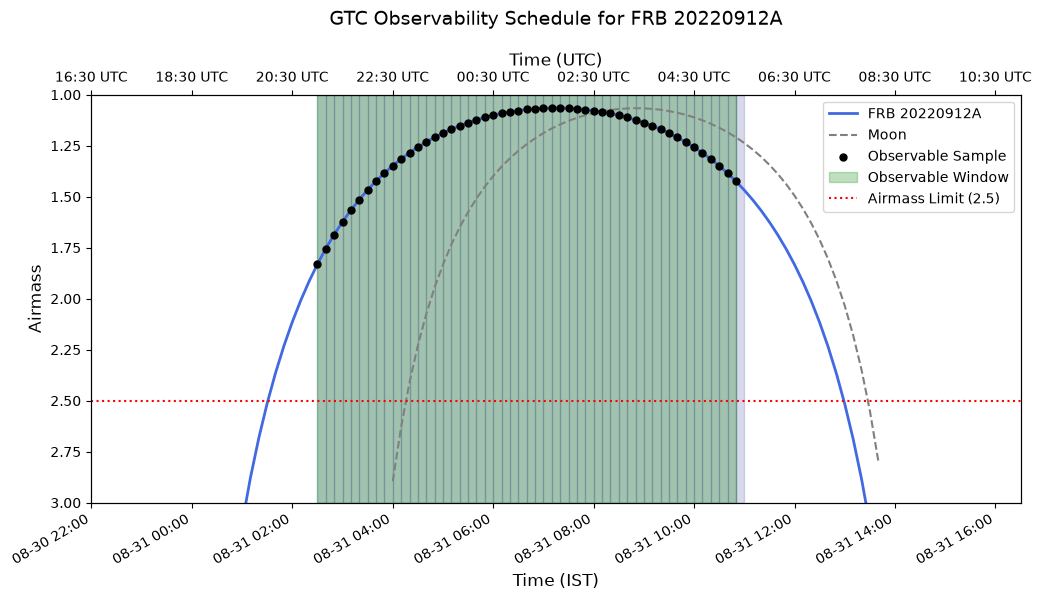

In [29]:
def stitch_windows(times_arr, visibility_mask):
    windows = []
    in_window = False
    start_i = 0
    for i, val in enumerate(visibility_mask):
        if val and not in_window:
            in_window = True
            start_i = i
        elif not val and in_window:
            in_window = False
            windows.append((start_i, i - 1))
    if in_window:
        windows.append((start_i, len(visibility_mask) - 1))
    return windows

windows = stitch_windows(times, preferred_visibility)
for s_idx, e_idx in windows:
    t_start, t_end = times[s_idx], times[e_idx]
    mid_idx = (s_idx + e_idx) // 2
    mid_moon = moon_labels[mid_idx]
    print(f"Window: {format_utc(t_start)} to {format_utc(t_end)}")
    print(f"   IST: {format_iitk(t_start)} to {format_iitk(t_end)}")
    print(f"   Duration: {((e_idx - s_idx + 1) * 10.0)/60.0:.2f} hr | Best Airmass: {np.nanmin(target_airmass[s_idx:e_idx+1]):.3f} | Midpoint Moon: {mid_moon}")

fig, ax1 = plt.subplots(figsize=(12, 6))
times_dt_iitk = [t.to_datetime(timezone=IITK_TIMEZONE) for t in times]

ax1.plot(times_dt_iitk, target_airmass, label="FRB 20220912A", color="royalblue", lw=2)
ax1.plot(times_dt_iitk, moon_airmass, label="Moon", color="gray", lw=1.5, ls="--")

obs_indices = np.where(preferred_visibility)[0]
ax1.scatter([times_dt_iitk[i] for i in obs_indices], target_airmass[obs_indices], color="black", s=25, zorder=5, label="Observable Sample")

for i in range(len(times) - 1):
    if sun_altitude[i] <= -18.0:
        ax1.axvspan(times_dt_iitk[i], times_dt_iitk[i+1], color="navy", alpha=0.15)

for s_idx, e_idx in windows:
    ax1.axvspan(times_dt_iitk[s_idx], times_dt_iitk[e_idx], color="green", alpha=0.25, label="Observable Window")

ax1.set_ylim(3.0, 1.0)
ax1.axhline(2.5, color="red", linestyle=":", label="Airmass Limit (2.5)")
ax1.set_ylabel("Airmass", fontsize=12)
ax1.set_xlabel("Time (IST)", fontsize=12)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d %H:%M", tz=IITK_TIMEZONE))
fig.autofmt_xdate()

ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
utc_ticks = ax1.get_xticks()
ax2.set_xticks(utc_ticks)
ax2.set_xticklabels([Time(matplotlib.dates.num2date(tick)).strftime("%H:%M UTC") for tick in utc_ticks])
ax2.set_xlabel("Time (UTC)", fontsize=12)

handles, labels = ax1.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax1.legend(by_label.values(), by_label.keys(), loc="upper right")

plt.title("GTC Observability Schedule for FRB 20220912A", pad=20, fontsize=14)
plt.savefig(OUTPUT_DIR / "frb_20220912a_gtc_airmass.png", bbox_inches="tight", dpi=200)
plt.show()

# Part F. All-sky observability (2 assessed marks + 2 optional bonus marks)

The previous parts established the physical ingredients needed for an observing decision. The next questions reuse those same ideas at increasing scale: first one source on one date, then a weekly all-sky GTC visibility animation over one year.

For Q19–Q20, use the geometric/airmass GTC visibility rule developed in the notebook: the source or sky position must be above the horizon, satisfy the GTC airmass limit, and be inside astronomical night. Do not include the Moon in these questions.


## Q19. Find the GTC visibility window of the repeating FRB on one date [2 marks]

Treat FRB 20220912A as a repeating source at its fixed ICRS/J2000 position. For `2026-09-01`, calculate its visibility from GTC across the full UTC day using the same HEALPix-style visibility logic: astronomical night, target altitude above the horizon, and target airmass no larger than 2.5. Report the start and end of each contiguous visibility interval in UTC and IIT Kanpur time, together with the total visible duration in hours.

This is a **single source**, not an all-sky calculation.


In [26]:
q19_times = Time("2026-09-01T00:00:00", scale="utc") + np.arange(0, 24*60 + 5, 5) * u.min
q19_frame = AltAz(obstime=q19_times, location=gtc_location)
q19_frb = frb_icrs.transform_to(q19_frame)
q19_sun = get_sun(q19_times).transform_to(q19_frame).alt.deg
q19_airmass = np.where(q19_frb.alt.deg > 0, q19_frb.secz.value, np.nan)

q19_mask = (q19_frb.alt.deg > 0.0) & (q19_airmass <= 2.5) & (q19_sun <= -18.0)
q19_windows = stitch_windows(q19_times, q19_mask)

print(f"Total Observable Duration: {np.sum(q19_mask) * (5.0 / 60.0):.2f} hours")
for s_idx, e_idx in q19_windows:
    print(f"Window: {format_utc(q19_times[s_idx])} to {format_utc(q19_times[e_idx])} (IST: {format_iitk(q19_times[s_idx])} to {format_iitk(q19_times[e_idx])})")

Total Observable Duration: 8.67 hours
Window: 2026-09-01 00:00:00 UTC to 2026-09-01 05:25:00 UTC (IST: 2026-09-01 05:30:00 IST to 2026-09-01 10:55:00 IST)
Window: 2026-09-01 20:55:00 UTC to 2026-09-02 00:00:00 UTC (IST: 2026-09-02 02:25:00 IST to 2026-09-02 05:30:00 IST)


## Q20. Generate a one-year GTC visibility animation [2 bonus marks]

Use the same **all-sky GTC visibility** model over the next year, starting on **2026-08-30** and sampled every 7 days. With a weekly cadence, the final sample within the 365-day window is **2027-08-29**. For each date, compute the HEALPix visibility map using the same GTC astronomical-night, altitude, and airmass conditions developed earlier.

Save each weekly map as a PNG frame and combine the frames into a GIF. The animation should show how the observable sky from GTC changes through the year. Use a moderate HEALPix resolution so that the calculation is practical.

Briefly describe what changes across the animation and why the observable region changes with date.

In [27]:
import imageio.v2 as imageio

NSIDE = 16
NPIX = hp.nside2npix(NSIDE)
theta, phi_hp = hp.pix2ang(NSIDE, np.arange(NPIX))
all_sky_coords = SkyCoord(ra=phi_hp * u.rad, dec=(np.pi/2 - theta) * u.rad, frame="icrs")

dates = Time("2026-08-30T00:00:00", scale="utc") + np.arange(0, 365, 7) * u.day
frame_filenames = []
gif_dir = OUTPUT_DIR / "q20_frames"
gif_dir.mkdir(exist_ok=True)

for i, date in enumerate(dates):
    night_steps = date + np.arange(20, 30, 0.5) * u.hour
    frame = AltAz(obstime=night_steps, location=gtc_location)
    dark_steps = night_steps[get_sun(night_steps).transform_to(frame).alt.deg <= -18.0]

    pix_hours = np.zeros(NPIX)
    if len(dark_steps) > 0:
        for t_step in dark_steps:
            sub_frame = AltAz(obstime=t_step, location=gtc_location)
            altaz = all_sky_coords.transform_to(sub_frame)
            valid = (altaz.alt.deg > 0) & (altaz.secz.value <= 2.5)
            pix_hours += valid * 0.5

    fig = plt.figure(figsize=(8, 5))
    hp.mollview(pix_hours, title=f"GTC Visibility: {date.strftime('%Y-%m-%d')}",
                unit="Hours Observable", min=0, max=8, fig=fig.number, hold=True)
    fname = gif_dir / f"frame_{i:02d}.png"
    plt.savefig(fname, bbox_inches="tight")
    plt.close()
    frame_filenames.append(fname)

gif_path = OUTPUT_DIR / "gtc_allsky_oneyear.gif"
with imageio.get_writer(gif_path, mode="I", duration=0.2) as writer:
    for fname in frame_filenames:
        writer.append_data(imageio.imread(fname))
print("Animation generated:", gif_path)

Animation generated: assignment_outputs/gtc_allsky_oneyear.gif


Across the year, the band of observable right ascensions drifts continuously eastward due to Earth's orbital motion around the Sun; the Sun moves roughly 1° east per day along the ecliptic, shifting the opposite region of the sky in darkness across the seasons.

## Submission checklist

- Restart the kernel and run every cell from top to bottom.
- Keep units attached during physical calculations.
- Use UTC internally; show IIT Kanpur time whenever reporting a civil clock time.
- Label Local Sidereal Time as LST, never IST.
- Keep the exact `visibility(altitude, airmass, sun_altitude, moon_separation)` interface.
- Confirm `assignment_outputs/frb_20220912a_gtc_airmass.png` exists and is non-empty.
- Confirm the Q20 one-year GTC GIF and its generated weekly frame PNGs are present.

## Compact glossary

- **Astropy quantity:** a numerical value stored together with a physical unit.
- **UTC:** the standard time scale used to identify an instant worldwide.
- **IST:** Indian Standard Time, the IIT Kanpur civil clock, UTC+05:30.
- **JD/MJD:** continuous astronomical day counts; MJD is JD minus 2,400,000.5.
- **ICRS:** a modern standard equatorial frame expressed with RA and Dec.
- **Galactic coordinates:** longitude $l$ and latitude $b$ referred to the Milky Way.
- **Ecliptic coordinates:** longitude $\lambda$ and latitude $\beta$ referred to Earth's orbital plane; longitude begins at the vernal equinox.
- **Angular separation:** the shortest great-circle angle between two directions on the celestial sphere.
- **Mollweide projection:** an equal-area elliptical map of the full celestial sphere; Matplotlib expects longitude and latitude in radians.
- **LST:** Local Sidereal Time, an astronomical angle determined by time and longitude.
- **Hour angle:** $H=\mathrm{LST}-\alpha$; zero at meridian transit.
- **Transit:** passage across the local meridian; usually the highest geometric altitude.
- **AltAz:** a horizon frame determined by observer location and time.
- **Zenith distance:** angular distance from the zenith, $z=90^\circ-h$.
- **Airmass:** approximate atmospheric path length relative to the zenith.
- **Astronomical darkness:** Sun altitude at or below $-18^\circ$ in this assignment.
- **Observable interval:** consecutive samples satisfying every printed condition.

- **HEALPix:** a hierarchical equal-area pixelization of the celestial sphere; each pixel can store an astronomical quantity such as visibility time.
- **Visibility time:** the amount of time a source satisfies the observing constraints during a specified interval.
- **Repeating FRB:** an FRB that can produce bursts on multiple occasions, so a future observing schedule can be planned for its fixed sky position.
